# Parsing JSON file

In [1]:
import pandas as pd
import numpy as np

df = pd.read_json("problems_data.jsonl",lines=True)

df.head()

,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


In [2]:
df.shape

(4112, 8)

In [3]:
df.columns

Index(['title', 'description', 'input_description', 'output_description',
       'sample_io', 'problem_class', 'problem_score', 'url'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4112 entries, 0 to 4111
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               4112 non-null   object 
 1   description         4112 non-null   object 
 2   input_description   4112 non-null   object 
 3   output_description  4112 non-null   object 
 4   sample_io           4112 non-null   object 
 5   problem_class       4112 non-null   object 
 6   problem_score       4112 non-null   float64
 7   url                 4112 non-null   object 
dtypes: float64(1), object(7)
memory usage: 257.1+ KB


In [5]:
df.isnull().sum()

title                 0
description           0
input_description     0
output_description    0
sample_io             0
problem_class         0
problem_score         0
url                   0
dtype: int64

This dataset includes other two columns, sample_io and url which are not relevant. Before converting this dataframe into csv, this columns are dropped.

In [6]:
cols_to_drop = ["sample_io", "url"]

df.drop(columns=cols_to_drop, inplace=True)

In [7]:
df.to_csv("parsed_problems_clean.csv", index=False)

In [8]:


df.head()

,title,description,input_description,output_description,problem_class,problem_score
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,hard,9.7
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,hard,9.7
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,hard,9.6
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,hard,9.6
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,hard,9.6


In [9]:
text_cols = ["title", "description", "input_description", "output_description"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("")
## add comment

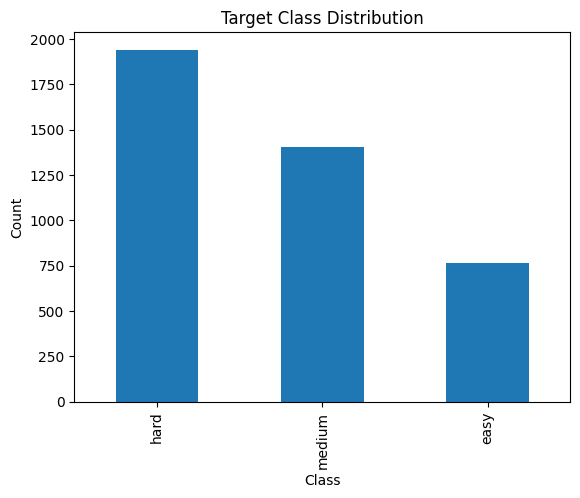

In [10]:
import matplotlib.pyplot as plt

df["problem_class"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [11]:
df["problem_score"].describe()

count    4112.000000
mean        5.114689
std         2.177770
min         1.100000
25%         3.300000
50%         5.200000
75%         6.900000
max         9.700000
Name: problem_score, dtype: float64

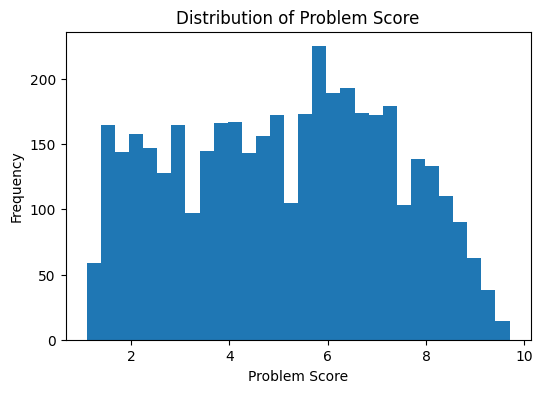

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["problem_score"], bins=30)
plt.xlabel("Problem Score")
plt.ylabel("Frequency")
plt.title("Distribution of Problem Score")
plt.show()

In [13]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


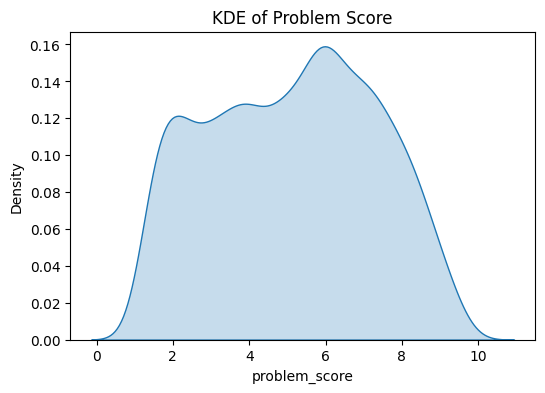

In [14]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.kdeplot(df["problem_score"], fill=True)
plt.title("KDE of Problem Score")
plt.show()

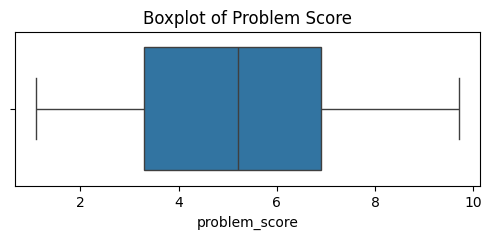

In [15]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["problem_score"])
plt.title("Boxplot of Problem Score")
plt.show()

In [16]:
df["problem_score"].skew(), df["problem_score"].kurtosis()

(np.float64(-0.026084020178964083), np.float64(-1.055532680847671))

Relationship with Target / Class

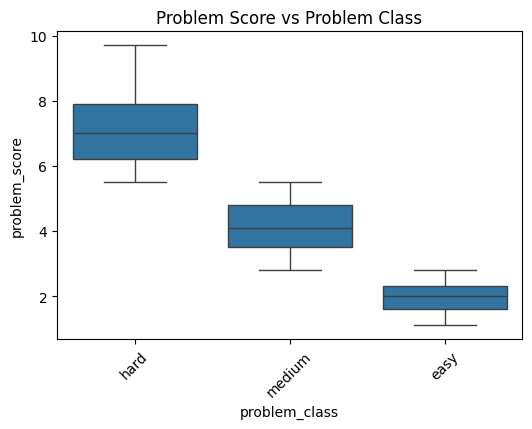

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="problem_class",
    y="problem_score",
    data=df
)
plt.xticks(rotation=45)
plt.title("Problem Score vs Problem Class")
plt.show()

# Data preprocessing

In [18]:
df["combined_text"] = (df["title"] + " " + df["description"] + " " + df["input_description"] + " " + df["output_description"])

In [19]:
#pd.set_option("display.max_colwidth", None) #For viewing the complete text

In [20]:
df["combined_text"].head(3)

0    Uuu Unununium (Uuu) was the name of the chemic...
1    House Building A number of eccentrics from cen...
2    Mario or Luigi Mario and Luigi are playing a g...
Name: combined_text, dtype: object

In [21]:
import re

def preprocessed_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["combined_text"] = df["combined_text"].apply(preprocessed_text)

In [22]:
df["combined_text"].isnull().sum()

np.int64(0)

In [23]:
df["combined_text"].str.len().describe()

count    4112.000000
mean     1440.859679
std       668.584832
min         7.000000
25%       989.000000
50%      1342.000000
75%      1785.000000
max      6191.000000
Name: combined_text, dtype: float64

In [24]:
df[["combined_text", "problem_class", "problem_score"]].head()

,combined_text,problem_class,problem_score
0,uuu unununium uuu was the name of the chemical...,hard,9.7
1,house building a number of eccentrics from cen...,hard,9.7
2,mario or luigi mario and luigi are playing a g...,hard,9.6
3,the wire ghost ofka is bending a copper wire s...,hard,9.6
4,barking up the wrong tree your dog spot is let...,hard,9.6


In [25]:
df.to_csv("parsed_problems_with_combined_text.csv", index=False)

# Feature engineering and feature extraction

Text length features

In [26]:
def text_length(text):
    num_chars = len(text)
    num_words = len(text.split())
    avg_word_len = num_chars / num_words if num_words > 0 else 0
    return [num_chars, num_words, avg_word_len]

Number of mathematical symbols

In [27]:
maths_symbols = r'[\+\-\*/%=<>^]'

def math_symbol_count(text):
    return len(re.findall(maths_symbols, text))

Keyword Frequency Features

In [28]:
keywords = ["graph", "tree", "dp", "dynamic programming","recursion", "greedy", "binary search","heap", "stack", "queue"]

def keyword_frequency(text):
    return [text.count(keyword) for keyword in keywords]

In [29]:
from scipy.sparse import csr_matrix, hstack

Combining above features

In [30]:
def build_aux_features(text_series):
    aux_features = []

    for text in text_series:
        features = []
        features.extend(text_length(text))          # 3 features
        features.append(math_symbol_count(text))    # 1 feature
        features.extend(keyword_frequency(text))    # len(keywords) features
        aux_features.append(features)

    return csr_matrix(np.array(aux_features) )

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf = TfidfVectorizer(
                        max_features=5000,
                        stop_words="english",
                        ngram_range=(1, 2) ) #max_df=0.9, min_df=2,

In [33]:
X_tfidf = tfidf.fit_transform(df["combined_text"])

In [34]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 320114 stored elements and shape (4112, 5000)>

In [35]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300, random_state=42)

In [36]:

X_tfidf_reduced = svd.fit_transform(X_tfidf)

In [37]:
print(X_tfidf_reduced.shape)

(4112, 300)


In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)

In [39]:
X_aux = build_aux_features(df["combined_text"])

In [40]:
X_aux

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13159 stored elements and shape (4112, 14)>

In [41]:
X_aux_scaled = scaler.fit_transform(X_aux)
print(X_aux_scaled.shape)

(4112, 14)


In [42]:
X = hstack([X_tfidf, X_aux_scaled])

In [43]:
X.shape

(4112, 5014)

In [44]:
X_aux[:5].toarray()

array([[1496.        ,  287.        ,    5.21254355,    0.        ,
           5.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ],
       [1247.        ,  247.        ,    5.048583  ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ],
       [1137.        ,  227.        ,    5.00881057,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ],
       [1241.        ,  237.        ,    5.23628692,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ],
       [2043.        ,  411.

# Model 1: Classification

In [45]:
y_class = df["problem_class"]   # classification target
y_score = df["problem_score"]   # regression target

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_class_train, y_class_test, y_score_train, y_score_test = train_test_split(X, y_class, y_score, test_size=0.2, random_state=42)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode TARGET variables
y_class_train_enc = le.fit_transform(y_class_train)
y_class_test_enc  = le.transform(y_class_test)

In [48]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, precision_score, roc_auc_score

In [50]:
class_models = { "Logistic": LogisticRegression(max_iter=3000, n_jobs=-1),

          "DecisionTree": DecisionTreeClassifier(max_depth=50, max_features=30 , random_state=42),

          "RandomForest": RandomForestClassifier(n_estimators=500, max_depth=50,
                                                 max_features=30, min_samples_split=10,
                                                 n_jobs=-1, random_state=42),

                 
          "LinearSVC": LinearSVC(C=1.5, max_iter=50000, class_weight="balanced")
                                   }


In [51]:
results = []

for model_name, model in class_models.items():
    
    # Train
    model.fit(X_train, y_class_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ---- Training metrics ----
    train_accuracy = accuracy_score(y_class_train, y_train_pred)
    train_f1 = f1_score(y_class_train, y_train_pred, average="weighted")
    train_precision = precision_score(y_class_train, y_train_pred, average="weighted")
    train_recall = recall_score(y_class_train, y_train_pred, average="weighted")

    # ---- Test metrics ----
    test_accuracy = accuracy_score(y_class_test, y_test_pred)
    test_f1 = f1_score(y_class_test, y_test_pred, average="weighted")
    test_precision = precision_score(y_class_test, y_test_pred, average="weighted")
    test_recall = recall_score(y_class_test, y_test_pred, average="weighted")

    # Store results
    results.append({
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Train F1": train_f1,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Test Accuracy": test_accuracy,
        "Test F1": test_f1,
        "Test Precision": test_precision,
        "Test Recall": test_recall
    })

    # ---- Console output (same style as your code) ----
    print(model_name)
    print("Model performance for Training set")
    print(f"- Accuracy: {train_accuracy:.3f}")
    print(f"- F1 score: {train_f1:.3f}")
    print(f"- Precision: {train_precision:.3f}")
    print(f"- Recall: {train_recall:.3f}")

    print("-" * 35)

    print("Model performance for Test set")
    print(f"- Accuracy: {test_accuracy:.3f}")
    print(f"- F1 score: {test_f1:.3f}")
    print(f"- Precision: {test_precision:.3f}")
    print(f"- Recall: {test_recall:.3f}")
    print("=" * 50)
    print("\n")


Logistic
Model performance for Training set
- Accuracy: 0.812
- F1 score: 0.808
- Precision: 0.824
- Recall: 0.812
-----------------------------------
Model performance for Test set
- Accuracy: 0.527
- F1 score: 0.511
- Precision: 0.515
- Recall: 0.527


DecisionTree
Model performance for Training set
- Accuracy: 0.699
- F1 score: 0.678
- Precision: 0.811
- Recall: 0.699
-----------------------------------
Model performance for Test set
- Accuracy: 0.480
- F1 score: 0.418
- Precision: 0.412
- Recall: 0.480


RandomForest
Model performance for Training set
- Accuracy: 0.980
- F1 score: 0.980
- Precision: 0.981
- Recall: 0.980
-----------------------------------
Model performance for Test set
- Accuracy: 0.546
- F1 score: 0.461
- Precision: 0.508
- Recall: 0.546


LinearSVC
Model performance for Training set
- Accuracy: 0.983
- F1 score: 0.983
- Precision: 0.983
- Recall: 0.983
-----------------------------------
Model performance for Test set
- Accuracy: 0.492
- F1 score: 0.497
- Precis

In [52]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Train F1,Train Precision,Train Recall,Test Accuracy,Test F1,Test Precision,Test Recall
0,Logistic,0.812405,0.808384,0.823500,0.812405,0.527339,0.510959,0.514796,0.527339
1,DecisionTree,0.698997,0.678462,0.810871,0.698997,0.479951,0.418478,0.412227,0.479951
2,RandomForest,0.979933,0.979679,0.980671,0.979933,0.545565,0.461369,0.508203,0.545565
3,LinearSVC,0.982670,0.982649,0.982672,0.982670,0.492102,0.496677,0.503400,0.492102


# Model 2: Regression

In [53]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score, mean_absolute_percentage_error

In [54]:
reg_models = {
    "Linear": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42),

    "RandomForest": RandomForestRegressor(n_estimators=500,
                                          random_state=42,
                                          max_depth=40,
                                          min_samples_split=5,
                                          n_jobs=-1),

    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                  max_depth=5, random_state=42),

    "KNN": KNeighborsRegressor(n_neighbors=5,
                               weights="uniform"
                              ),

    "SVR": SVR(kernel="rbf")
}


In [55]:
reg_results = []

for model_name, model in reg_models.items():
    
    # Train model
    model.fit(X_train, y_score_train)

    # Predictions
    y_train_score_pred = model.predict(X_train)
    y_test_score_pred = model.predict(X_test)

    # ---- Training set performance ----
    model_train_mae = mean_absolute_error(y_score_train, y_train_score_pred)
    model_train_mse = mean_squared_error(y_score_train, y_train_score_pred)
    model_train_rmse = np.sqrt(model_train_mse)
    model_train_r2 = r2_score(y_score_train, y_train_score_pred)

    # ---- Test set performance ----
    model_test_mae = mean_absolute_error(y_score_test, y_test_score_pred)
    model_test_mse = mean_squared_error(y_score_test, y_test_score_pred)
    model_test_rmse = np.sqrt(model_test_mse)
    model_test_r2 = r2_score(y_score_test, y_test_score_pred)

    
    reg_results.append({
        "Model": model_name,
        "Train MAE": model_train_mae,
        "Train MSE": model_train_mse,
        "Train RMSE": model_train_rmse,
        "Train R2": model_train_r2,
        "Test MAE": model_test_mae,
        "Test MSE": model_test_mse,
        "Test RMSE": model_test_rmse,
        "Test R2": model_test_r2
    })

    print(model_name)

    print("Model performance for Training set")
    print("- MAE: {:.3f}".format(model_train_mae))
    print("- MSE: {:.3f}".format(model_train_mse))
    print("- RMSE: {:.3f}".format(model_train_rmse))
    print("- R2: {:.3f}".format(model_train_r2))

    print("-" * 35)

    print("Model performance for Test set")
    print("- MAE: {:.3f}".format(model_test_mae))
    print("- MSE: {:.3f}".format(model_test_mse))
    print("- RMSE: {:.3f}".format(model_test_rmse))
    print("- R2: {:.3f}".format(model_test_r2))

    print("=" * 50)
    print("\n")


Linear
Model performance for Training set
- MAE: 0.002
- MSE: 0.001
- RMSE: 0.038
- R2: 1.000
-----------------------------------
Model performance for Test set
- MAE: 3.097
- MSE: 14.933
- RMSE: 3.864
- R2: -2.111


DecisionTree
Model performance for Training set
- MAE: 1.387
- MSE: 3.030
- RMSE: 1.741
- R2: 0.357
-----------------------------------
Model performance for Test set
- MAE: 1.924
- MSE: 5.466
- RMSE: 2.338
- R2: -0.139


RandomForest
Model performance for Training set
- MAE: 0.705
- MSE: 0.716
- RMSE: 0.846
- R2: 0.848
-----------------------------------
Model performance for Test set
- MAE: 1.687
- MSE: 4.158
- RMSE: 2.039
- R2: 0.134


GradientBoosting
Model performance for Training set
- MAE: 1.101
- MSE: 1.694
- RMSE: 1.301
- R2: 0.641
-----------------------------------
Model performance for Test set
- MAE: 1.684
- MSE: 4.109
- RMSE: 2.027
- R2: 0.144


KNN
Model performance for Training set
- MAE: 1.501
- MSE: 3.294
- RMSE: 1.815
- R2: 0.301
------------------------

In [56]:
reg_results_df = pd.DataFrame(reg_results)
reg_results_df

,Model,Train MAE,Train MSE,Train RMSE,Train R2,Test MAE,Test MSE,Test RMSE,Test R2
0,Linear,0.001838,0.001465,0.038274,0.999689,3.097258,14.933293,3.864362,-2.110944
1,DecisionTree,1.386886,3.029748,1.740617,0.357185,1.924408,5.465880,2.337922,-0.138667
2,RandomForest,0.704661,0.716441,0.846428,0.847994,1.687198,4.157980,2.039112,0.133798
3,GradientBoosting,1.100869,1.693775,1.301451,0.640636,1.683727,4.108628,2.026975,0.144079
4,KNN,1.500772,3.293692,1.814853,0.301185,1.829429,4.882176,2.209565,-0.017068
5,SVR,1.762243,4.305473,2.074963,0.086517,1.817457,4.662496,2.159281,0.028696


# Hyperparameter optimization

In [57]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

## Classification

In [86]:
rf_params = {"n_estimators": [500],
            "max_depth": [50],
            "min_samples_split": [10, 20],
             "max_features": [30,40]
            }

In [87]:
gridcv_class_models = [
    ("RandomForestClassifier", RandomForestClassifier(), rf_params),
]

In [88]:
model_param = {}

for name, model, params in gridcv_class_models:
    grid_class = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="accuracy",
        cv=5,
        verbose=2,
        n_jobs=-1
    )

    grid_class.fit(X_train, y_class_train)

    model_param[name] = grid_class.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [89]:
print("\n--- Best Parameters Found for Classification---")
for name, params in model_param.items():
    print(f"\nModel: {name}")
    print(f"Best Parameters: {params}")
    
print("Best CV Score (accuracy):", grid_class.best_score_)


--- Best Parameters Found for Classification---

Model: RandomForestClassifier
Best Parameters: {'max_depth': 50, 'max_features': 40, 'min_samples_split': 10, 'n_estimators': 500}
Best CV Score (accuracy): 0.49436834094368337


## Regression

In [62]:
rf_reg_params = {
    "n_estimators": [300,500],
    "max_depth": [25,40],
    "min_samples_split": [5, 10]
}

In [63]:
grid_cv_reg_models = [
    ("RandomForestRegressor", RandomForestRegressor(), rf_reg_params),
]

In [64]:
model_param_reg = {}

for name, model, params in grid_cv_reg_models:
    grid_reg = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="neg_mean_absolute_error",
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    grid_reg.fit(X_train, y_score_train)

    model_param[name] = grid_reg.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [66]:
print("Best Regression Model Parameters:")
print(grid_reg.best_params_)

print("Best CV Score (MAE):", grid_reg.best_score_)

Best Regression Model Parameters:
{'max_depth': 40, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Score (MAE): -1.702073335691032


# Best models

In [90]:
best_clf_model = grid_class.best_estimator_
print(best_clf_model)

RandomForestClassifier(max_depth=50, max_features=40, min_samples_split=10,
                       n_estimators=500)


In [91]:
best_reg_model = grid_reg.best_estimator_
print(best_reg_model)

RandomForestRegressor(max_depth=40, min_samples_split=10, n_estimators=300)


# Visualization

In [92]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_class_train_enc = label_encoder.fit_transform(y_class_train)
y_class_test_enc = label_encoder.transform(y_class_test)


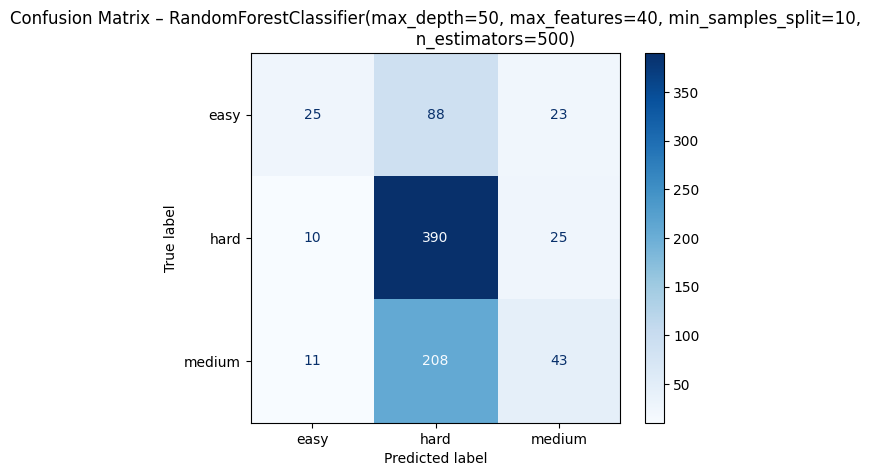

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_class = best_clf_model.predict(X_test)
pred_class_enc = label_encoder.transform(pred_class)

cm = confusion_matrix(y_class_test_enc, pred_class_enc)

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix – {best_clf_model}")
plt.show()

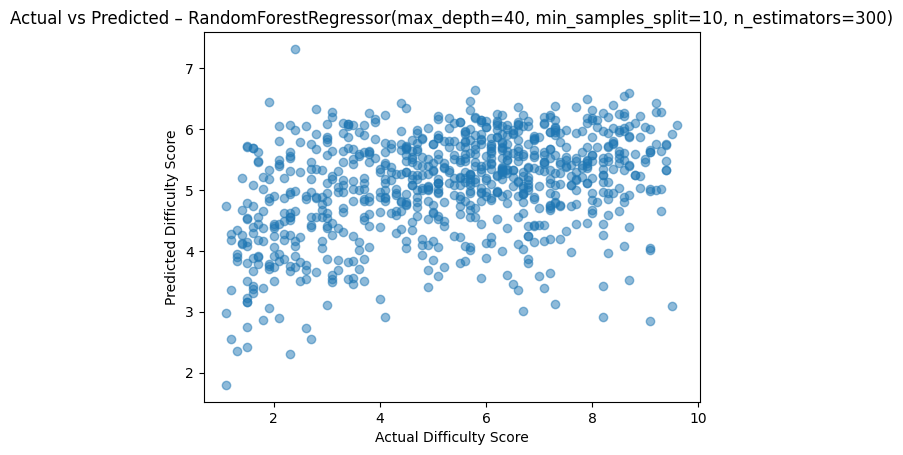

In [95]:
pred_score = best_reg_model.predict(X_test)

plt.scatter(y_score_test, pred_score, alpha=0.5)
plt.xlabel("Actual Difficulty Score")
plt.ylabel("Predicted Difficulty Score")
plt.title(f"Actual vs Predicted – {best_reg_model}")
plt.show()

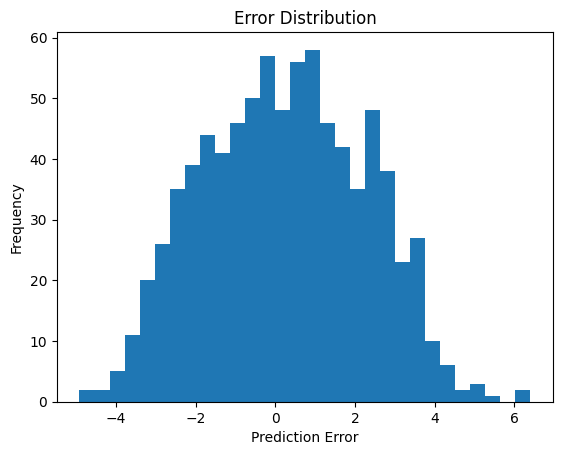

In [96]:
errors = y_score_test - pred_score

plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()

# Saving Final Models

In [97]:
import joblib

joblib.dump(best_clf_model, "best_clf_model.pkl")
joblib.dump(best_reg_model, "best_reg_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [98]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(keywords, "keywords_list.pkl")

['keywords_list.pkl']

In [99]:
joblib.dump(scaler, "aux_scaler.pkl")

['aux_scaler.pkl']